## Prétraitement

In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data import load_data_excel, convert_numeric_columns
from src.features import onehot_encode_categorical_feature, get_simplified_names
from src.experiments import (
    prepare_data_random_split, train_xgboost_models
)
from src.visu import plot_ml_results
from src.import_data import import_moyennes

# Load data
data = load_data_excel('../data/sources/Donnees_IA_2025.xlsx')

# Define variables
vars_expl = [
    "MS % brut", "PB % brut", "CB % brut", "MGR % brut", "MM % brut",
    "NDF % brut", "ADF % brut", "Lignine % brut", "Amidon % brut", "Sucres % brut"
]

vars_cibles = [
    "EB (kcal) kcal/kg brut", "ED porc croissance (kcal) kcal/kg brut",
    "EM porc croissance (kcal) kcal/kg brut", "EN porc croissance (kcal) kcal/kg brut",
    "EMAn coq (kcal) kcal/kg brut", "EMAn poulet (kcal) kcal/kg brut",
    "UFL 2018 par kg brut", "UFV 2018 par kg brut", "PDIA 2018 g/kg brut",
    "PDI 2018 g/kg brut", "BalProRu 2018 g/kg brut"
]

# Convert numeric columns
data = convert_numeric_columns(data, vars_expl + vars_cibles)

# Get simplified names
simplified_names = get_simplified_names()

print(f" Data loaded: {len(data)} observations")

# Import du ficheir des moyennes 

moyenne_df = import_moyennes(path= "../data/sources/Moyenne_Feedtables.csv")

print(f" Moyenne loaded: {len(moyenne_df)} observations")

 Data loaded: 6376 observations
 Moyenne loaded: 73 observations


## Régression XGBoost et test sur les valeurs de table (In Distribution) - Importance des caractéristiques et test de robustesse

Testez comment les performances du modèle varient en fonction des différentes caractéristiques d'entrée et des encodages catégoriels.

### Scenario 5: Toutes les variables chimiques + Nom (Encodés)

In [2]:
# Scenario 5: All chemical features + Nom (One-Hot Encoded)
X_train_nom, X_test_nom, y_train_nom, y_test_nom = prepare_data_random_split(
    data, vars_expl, vars_cibles, test_size=0.2, random_state=42
)

# Keep track of indices for one-hot encoding
indices_train_nom = X_train_nom.index
indices_test_nom = X_test_nom.index

# Add one-hot encoded Nom feature
X_train_nom, X_test_nom = onehot_encode_categorical_feature(
    X_train_nom, X_test_nom, data, "Nom", indices_train_nom, indices_test_nom, drop_first=False
)

# Clean column names to remove special characters
X_train_nom.columns = X_train_nom.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test_nom.columns = X_test_nom.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)

results_nom, metrics_nom, models_nom = train_xgboost_models(
    X_train_nom, X_test_nom, y_train_nom, y_test_nom,
    vars_cibles, simplified_names, random_state=42
)

print("\nScenario 5: All Chemical Features + Nom (One-Hot Encoded)")
print(f"Train size: {len(X_train_nom)}, Test size: {len(X_test_nom)}")
print(f"R² variance weighted: {metrics_nom['R2_variance_weighted']:.4f}")
print(f"Number of features (Chemical + One-Hot encoded Nom): {X_train_nom.shape[1]}")
print(results_nom[['Variable cible', 'R2', 'MAE', 'RMSE']].to_string(index=False))


Scenario 5: All Chemical Features + Nom (One-Hot Encoded)
Train size: 5100, Test size: 1276
R² variance weighted: 0.9914
Number of features (Chemical + One-Hot encoded Nom): 83
Variable cible     R2   MAE  RMSE
            EB 0.9931 30.21 51.78
       ED porc 0.9915 46.73 78.28
       EM porc 0.9903 44.47 80.26
       EN porc 0.9944 33.63 53.53
      EMAn coq 0.9901 49.05 80.26
   EMAn poulet 0.9904 46.46 76.77
           UFL 0.9894  0.02  0.03
           UFV 0.9908  0.02  0.03
          PDIA 0.9954  1.87  5.60
           PDI 0.9940  2.12  6.30
      BalProRu 0.9966  2.69  5.64


### Scenario 6: MS + PB + Nom (Encoded)

In [3]:
# Scenario 6: MS + PB + Nom (One-Hot Encoded)
features_mspb = ["MS % brut", "PB % brut"]
X_train_mspb_nom, X_test_mspb_nom, y_train_mspb_nom, y_test_mspb_nom = prepare_data_random_split(
    data, features_mspb, vars_cibles, test_size=0.2, random_state=42
)

# Keep track of indices for one-hot encoding
indices_train_mspb = X_train_mspb_nom.index
indices_test_mspb = X_test_mspb_nom.index

# Add one-hot encoded Nom feature
X_train_mspb_nom, X_test_mspb_nom = onehot_encode_categorical_feature(
    X_train_mspb_nom, X_test_mspb_nom, data, "Nom", indices_train_mspb, indices_test_mspb, drop_first=False
)

# Clean column names to remove special characters
X_train_mspb_nom.columns = X_train_mspb_nom.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test_mspb_nom.columns = X_test_mspb_nom.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)

results_mspb_nom, metrics_mspb_nom, models_mspb_nom = train_xgboost_models(
    X_train_mspb_nom, X_test_mspb_nom, y_train_mspb_nom, y_test_mspb_nom,
    vars_cibles, simplified_names, random_state=42
)

print("\nScenario 6: MS + PB + Nom (One-Hot Encoded)")
print(f"Train size: {len(X_train_mspb_nom)}, Test size: {len(X_test_mspb_nom)}")
print(f"R² variance weighted: {metrics_mspb_nom['R2_variance_weighted']:.4f}")
print(f"Number of features (MS + PB + One-Hot encoded Nom): {X_train_mspb_nom.shape[1]}")
print(results_mspb_nom[['Variable cible', 'R2', 'MAE', 'RMSE']].to_string(index=False))


Scenario 6: MS + PB + Nom (One-Hot Encoded)
Train size: 5100, Test size: 1276
R² variance weighted: 0.9648
Number of features (MS + PB + One-Hot encoded Nom): 75
Variable cible     R2    MAE   RMSE
            EB 0.9669  67.65 113.59
       ED porc 0.9645 106.44 159.62
       EM porc 0.9632 103.42 156.12
       EN porc 0.9664  84.95 130.90
      EMAn coq 0.9631  99.96 154.91
   EMAn poulet 0.9650  95.85 146.16
           UFL 0.9677   0.03   0.05
           UFV 0.9678   0.04   0.06
          PDIA 0.9982   1.41   3.52
           PDI 0.9981   1.65   3.52
      BalProRu 0.9986   2.21   3.59


In [4]:
def mask_and_impute_individual(
    X_test,
    data_full,
    moyenne_df,
    maskable_vars,
    k,
    rng
):
    """
    Masque k variables parmi maskable_vars pour chaque individu du test,
    sans toucher aux variables protégées ni aux colonnes OHE.
    """

    X_masked = X_test.copy()

    for idx in X_masked.index:

        # Tirage aléatoire parmi les variables autorisées
        vars_to_mask = rng.choice(maskable_vars, size=k, replace=False)

        nom = data_full.loc[idx, "Nom"]

        # Remplacement par feedtable
        X_masked.loc[idx, vars_to_mask] = moyenne_df.loc[nom, vars_to_mask]

    return X_masked

from sklearn.metrics import r2_score

def compute_uniform_r2(model, X_test, y_test, target_cols):
    
    # Prédictions multi-output
    y_pred = model.predict(X_test)
    
    # Matrices complètes
    y_test_all = y_test[target_cols].values
    
    # Même logique que dans train_xgboost_models
    r2_uniform = r2_score(
        y_test_all,
        y_pred,
        multioutput='uniform_average'
    )
    
    return r2_uniform

In [5]:
from xgboost import XGBRegressor

# Scenario 7: All chemical features qu'on retire + Nom (One-Hot Encoded)
X_train_ret, X_test_ret, y_train_ret, y_test_ret = prepare_data_random_split(
    data, vars_expl, vars_cibles, test_size=0.2, random_state=42
)

# Keep track of indices for one-hot encoding
indices_train_ret = X_train_ret.index
indices_test_ret = X_test_ret.index

# Add one-hot encoded Nom feature
X_train_ret, X_test_ret = onehot_encode_categorical_feature(
    X_train_ret, X_test_ret, data, "Nom", indices_train_ret, indices_test_ret, drop_first=False
)

# Clean column names to remove special characters
X_train_ret.columns = X_train_ret.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test_ret.columns = X_test_ret.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)

model_XGB = XGBRegressor(random_state=42)
model_XGB.fit(X_train_ret, y_train_ret)

rng = np.random.default_rng(42)

protected_vars = ["MS % brut", "PB % brut"]

maskable_vars = [
    v for v in vars_expl if v not in protected_vars
]

p = len(maskable_vars)

R2_individual_masking = []

# =========================
# Boucle robustesse
# =========================
for k in range(1, p + 1):

    X_test_masked = mask_and_impute_individual(
        X_test_ret,
        data,
        moyenne_df,
        maskable_vars,
        k,
        rng
    )

    r2_k = compute_uniform_r2(
        model_XGB,       # ← on passe directement le modèle
        X_test_masked,
        y_test_ret,
        vars_cibles
    )

    R2_individual_masking.append(r2_k)

print(R2_individual_masking)

[0.9859397437498416, 0.9710060422565707, 0.9611388703649503, 0.9552934619524787, 0.9446690285154105, 0.934012038045163, 0.9256438816183508, 0.9137588015503909]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# =========================
# Paramètres
# =========================
protected_vars = ["MS % brut", "PB % brut"]
maskable_vars = [v for v in vars_expl if v not in protected_vars]
p = len(maskable_vars)  # k va de 1 à p
k_values = np.arange(1, p + 1)

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Stockage: R2 par k et par fold => shape (p, n_splits)
R2_k_folds = np.full((p, n_splits), np.nan, dtype=float)

# =========================
# CV 10 folds
# =========================
for fold_id, (train_idx, test_idx) in enumerate(kf.split(data)):

    # Split
    X_train = data.iloc[train_idx][vars_expl].copy()
    X_test  = data.iloc[test_idx][vars_expl].copy()
    y_train = data.iloc[train_idx][vars_cibles].copy()
    y_test  = data.iloc[test_idx][vars_cibles].copy()

    # OHE Nom (ne pas toucher ensuite)
    X_train, X_test = onehot_encode_categorical_feature(
        X_train, X_test, data, "Nom",
        X_train.index, X_test.index,
        drop_first=False
    )

    # Nettoyage noms colonnes
    X_train.columns = (X_train.columns
                       .str.replace('[', '_', regex=False)
                       .str.replace(']', '_', regex=False)
                       .str.replace('<', '_', regex=False))
    X_test.columns = (X_test.columns
                      .str.replace('[', '_', regex=False)
                      .str.replace(']', '_', regex=False)
                      .str.replace('<', '_', regex=False))

    # Entraînement UNE fois pour ce fold (modèle multi-output)
    model = XGBRegressor(random_state=42)
    model.fit(X_train, y_train)

    # RNG dédié au fold (pour que chaque fold ait un masquage différent mais reproductible)
    rng_fold = np.random.default_rng(42 + fold_id)

    # =========================
    # Boucle sur k (masquage individuel sur le test uniquement)
    # =========================
    for k in range(1, p + 1):

        X_test_masked = mask_and_impute_individual(
            X_test,          # contient aussi les colonnes OHE (qu'on ne modifie pas)
            data,            # pour récupérer Nom via index
            moyenne_df,      # feedtable
            maskable_vars,   # uniquement chimiques hors MS/PB
            k,
            rng_fold
        )

        # Prédiction + R² uniform_average (comme ta fonction train_xgboost_models)
        y_pred = model.predict(X_test_masked)

        r2_k = r2_score(
            y_test[vars_cibles].values,
            y_pred,
            multioutput="uniform_average"
        )

        R2_k_folds[k - 1, fold_id] = r2_k

# =========================
# Moyenne + écart-type par k (sur les folds)
# =========================
mean_r2 = np.nanmean(R2_k_folds, axis=1)                  # shape (p,)
std_r2  = np.nanstd(R2_k_folds, axis=1, ddof=1)           # shape (p,)
sem_r2  = std_r2 / np.sqrt(np.sum(~np.isnan(R2_k_folds), axis=1))

# Choix barres d'erreur
yerr = std_r2       # écart-type
# yerr = sem_r2     # ou SEM


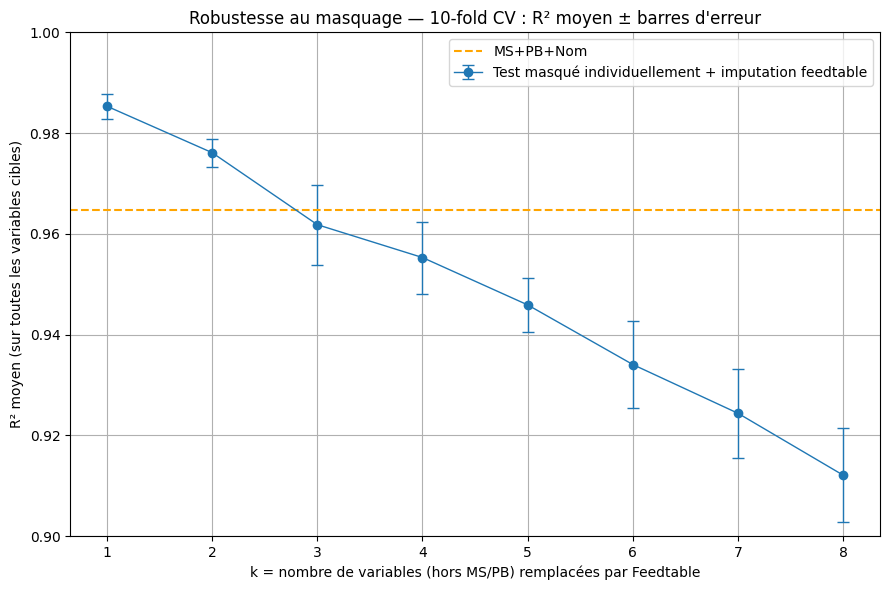

In [7]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    k_values,
    mean_r2,
    yerr=yerr,
    marker="o",
    capsize=4,
    linewidth=1,
    label="Test masqué individuellement + imputation feedtable"
)

plt.xlabel("k = nombre de variables (hors MS/PB) remplacées par Feedtable")
plt.ylabel("R² moyen (sur toutes les variables cibles)")
plt.title("Robustesse au masquage — 10-fold CV : R² moyen ± barres d'erreur")
plt.axhline(
    y=metrics_mspb_nom['R2_variance_weighted'],
    linestyle="--",
    linewidth=1.5,
    label="MS+PB+Nom",
    color = 'orange'
)
plt.ylim((0.9, 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comparaison total des différents scénarios

In [8]:
# Extended comparison with all 6 scenarios
comparison_all_df = pd.DataFrame({
    'Scenario': [
        'Total (Noms + physico-chimiques)',
        'MS + PB + Nom (OHE)'
    ],
    'R² Variance Weighted': [
        metrics_nom['R2_variance_weighted'],
        metrics_mspb_nom['R2_variance_weighted']
    ],
    'R² Std Dev': [
        results_nom['R2'].std(),
        results_mspb_nom['R2'].std()
    ]
})

# Sort by R² in descending order (highest to lowest)
comparison_all_df = comparison_all_df.sort_values('R² Variance Weighted', ascending=False).reset_index(drop=True)


EXTENDED COMPARISON TABLE - All 6 Scenarios (sorted by R² descending)
                        Scenario  R² Variance Weighted  R² Std Dev
Total (Noms + physico-chimiques)                0.9914    0.002444
             MS + PB + Nom (OHE)                0.9648    0.015368


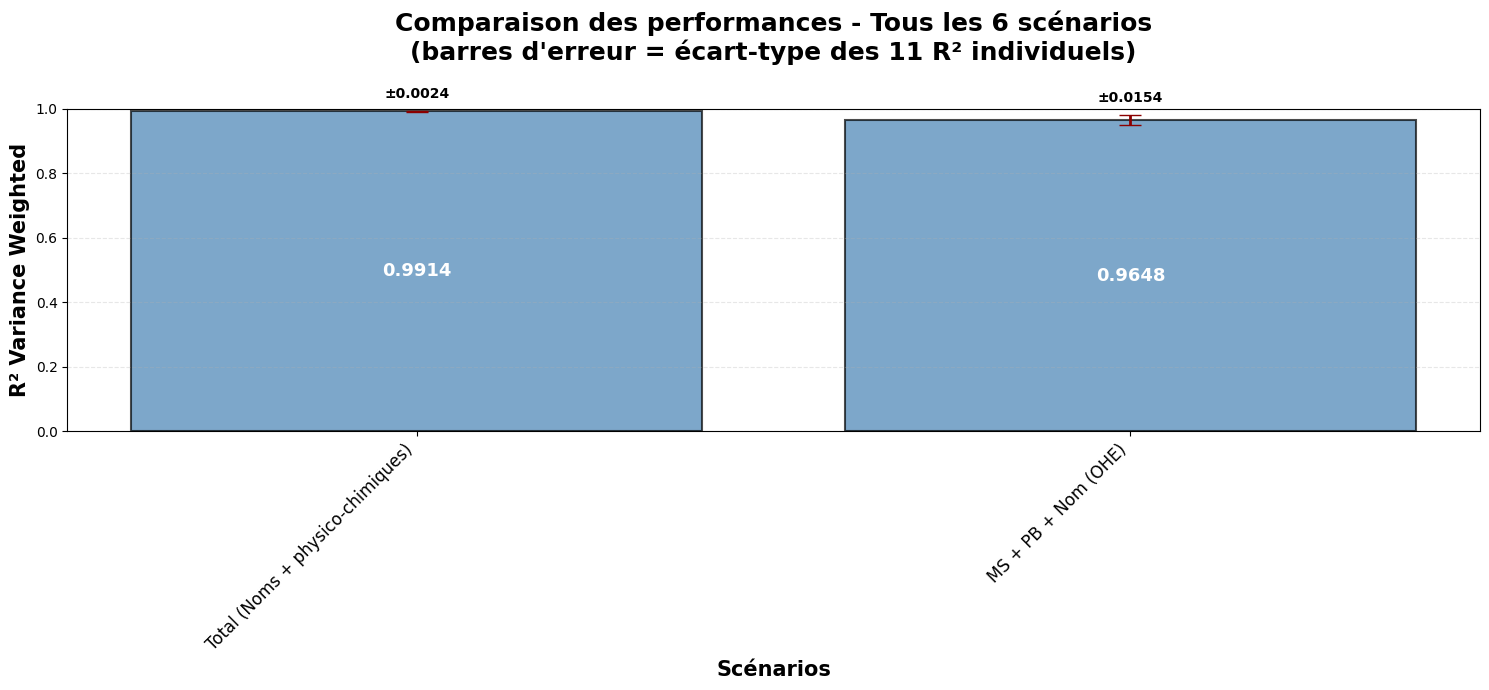

In [9]:

print("\n" + "="*80)
print("EXTENDED COMPARISON TABLE - All 6 Scenarios (sorted by R² descending)")
print("="*80)
print(comparison_all_df.to_string(index=False))

# Plot all 6 scenarios with error bars
fig, ax = plt.subplots(figsize=(15, 7))

x_pos = np.arange(len(comparison_all_df))
ax.bar(x_pos, comparison_all_df['R² Variance Weighted'], 
       yerr=comparison_all_df['R² Std Dev'],
       capsize=8, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5,
       error_kw={'linewidth': 2, 'ecolor': 'darkred'})

ax.set_ylabel('R² Variance Weighted', fontsize=15, fontweight='bold')
ax.set_xlabel('Scénarios', fontsize=15, fontweight='bold')
ax.set_title('Comparaison des performances - Tous les 6 scénarios\n(barres d\'erreur = écart-type des 11 R² individuels)', 
             fontsize=18, fontweight='bold', pad=35)
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_all_df['Scenario'], fontsize=12, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1)

# Add value labels on bars (WHITE TEXT INSIDE BARS)
for i, (val, std) in enumerate(zip(comparison_all_df['R² Variance Weighted'], comparison_all_df['R² Std Dev'])):
    # Text inside the bar (white)
    ax.text(i, val/2, f'{val:.4f}', 
            ha='center', va='center', fontsize=13, fontweight='bold', color='white')
    # Text above the bar (black, for error info)
    ax.text(i, val + std + 0.03, f'±{std:.4f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../reports/figures/comparison_all_scenarios.png')
plt.show()

All + Nom only -> modèle parfait, plot les résidus pour diapo --> validation croisée + refaire un graphique propre de l'importance des features (barplot)


Baseline -> prédire les valeurs de table moyenne.




RMSE COMPARISON TABLE (avec Erreur Standard)
                        Scenario  RMSE Mean  RMSE Std Dev   RMSE SE
Total (Noms + physico-chimiques)  39.861818     36.160209 10.902713
             MS + PB + Nom (OHE)  79.276364     74.936550 22.594220


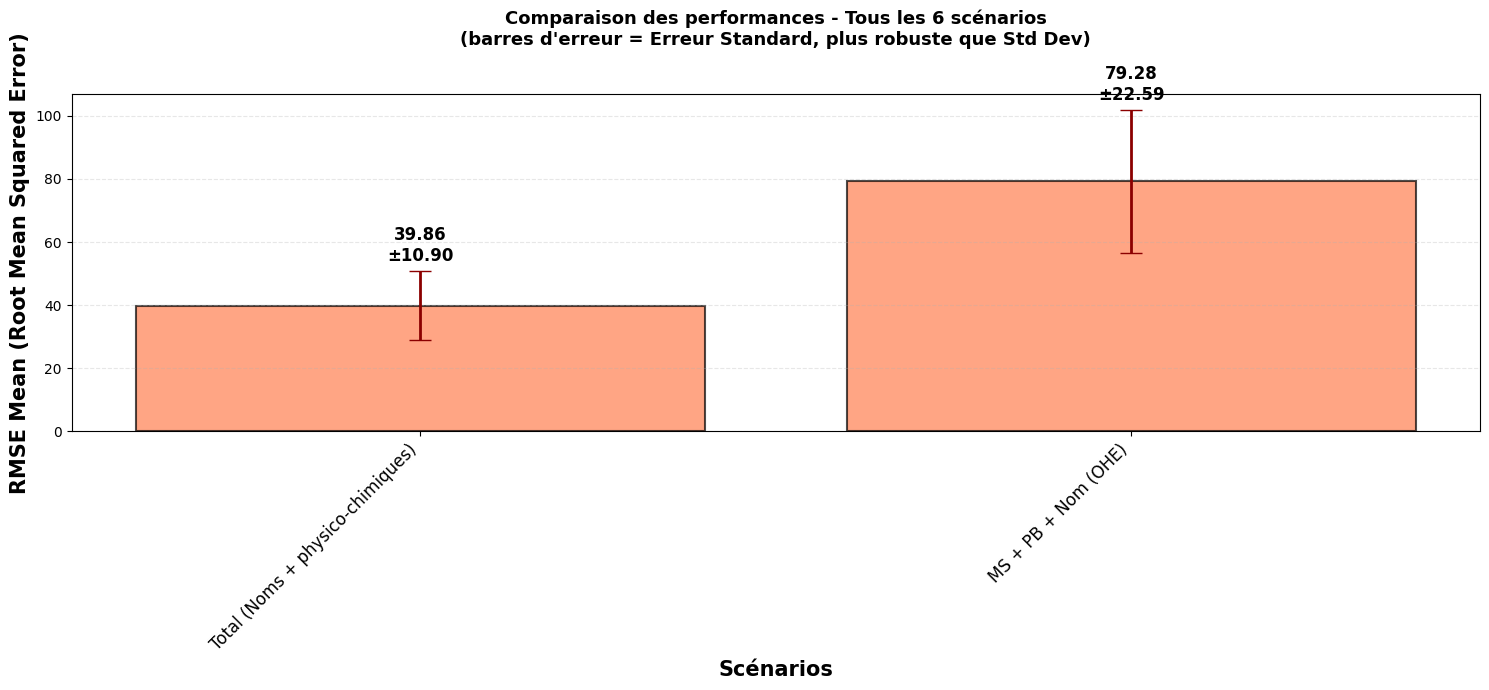

In [10]:
# Même figure mais avec représentation du RMSE à la place du R², pour voir si les tendances sont similaires
# Créer une DataFrame avec RMSE
comparison_rmse_df = pd.DataFrame({
    'Scenario': [
        'Total (Noms + physico-chimiques)',
        'MS + PB + Nom (OHE)'
    ],
    'RMSE Mean': [
        results_nom['RMSE'].mean(),
        results_mspb_nom['RMSE'].mean()
    ],
    'RMSE Std Dev': [
        results_nom['RMSE'].std(),
        results_mspb_nom['RMSE'].std()
    ]
})

# Sort by RMSE in ascending order (lower is better)
comparison_rmse_df = comparison_rmse_df.sort_values('RMSE Mean', ascending=True).reset_index(drop=True)

# Calculer l'erreur standard (plus robuste que l'écart-type brut)
# L'erreur standard = std / sqrt(n) où n = nombre de variables cibles
n_targets = len(vars_cibles)
comparison_rmse_df['RMSE SE'] = comparison_rmse_df['RMSE Std Dev'] / np.sqrt(n_targets)

print("\n" + "="*80)
print("RMSE COMPARISON TABLE (avec Erreur Standard)")
print("="*80)
print(comparison_rmse_df[['Scenario', 'RMSE Mean', 'RMSE Std Dev', 'RMSE SE']].to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 7))
x_pos = np.arange(len(comparison_rmse_df))

# Utiliser l'erreur standard au lieu de l'écart-type pour les barres d'erreur
ax.bar(x_pos, comparison_rmse_df['RMSE Mean'], 
       yerr=comparison_rmse_df['RMSE SE'],
       capsize=8, alpha=0.7, color='coral', edgecolor='black', linewidth=1.5,
       error_kw={'linewidth': 2, 'ecolor': 'darkred'})
ax.set_ylabel('RMSE Mean (Root Mean Squared Error)', fontsize=15, fontweight='bold')
ax.set_xlabel('Scénarios', fontsize=15, fontweight='bold')
ax.set_title('Comparaison des performances - Tous les 6 scénarios\n(barres d\'erreur = Erreur Standard, plus robuste que Std Dev)', 
             fontsize=13, fontweight='bold', pad=35)
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_rmse_df['Scenario'], fontsize=12, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (val, se) in enumerate(zip(comparison_rmse_df['RMSE Mean'], comparison_rmse_df['RMSE SE'])):
    ax.text(i, val + se + 2, f'{val:.2f}\n±{se:.2f}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/comparison_all_scenarios_rmse.png')
plt.show()

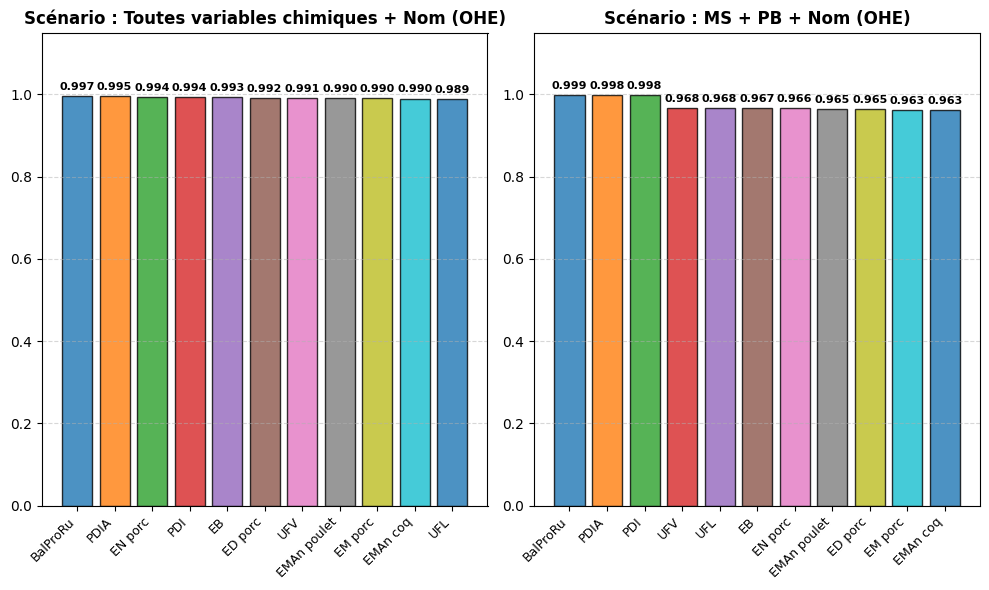

In [11]:
# Grid of R² by target variable for all 6 scenarios
all_detailed_results = {
    'Toutes variables chimiques + Nom (OHE)': results_nom,
    'MS + PB + Nom (OHE)': results_mspb_nom
}

# Alternative visualization for detailed results
fig = plot_ml_results(
    all_detailed_results,
    y_col='R2',
    figsize=(10,6)
)
plt.show()